In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from wordcloud import WordCloud
from collections import Counter
import random
np.random.seed(42)
random.seed(42)
import services.utils as ut

In [3]:
data_df = ut.load_data('customer_support_tickets.csv')
if data_df is not None:
    print("Data loaded successfully")
print(data_df.head())

Data loaded successfully
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   

In [4]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

There are around 8469 entries present in the data set

In [5]:
for column in data_df.columns:
    print(f"{column}: {data_df[column].isnull().sum()} null values")

Ticket ID: 0 null values
Customer Name: 0 null values
Customer Email: 0 null values
Customer Age: 0 null values
Customer Gender: 0 null values
Product Purchased: 0 null values
Date of Purchase: 0 null values
Ticket Type: 0 null values
Ticket Subject: 0 null values
Ticket Description: 0 null values
Ticket Status: 0 null values
Resolution: 5700 null values
Ticket Priority: 0 null values
Ticket Channel: 0 null values
First Response Time: 2819 null values
Time to Resolution: 5700 null values
Customer Satisfaction Rating: 5700 null values


We have many null values but these null values are not present in the columns which is required for topic modelling. Hence we can ignore it.
For the topic modelling we will mainly focus on the ticket description but we will proceed to do the EDA on all the columns to understand the data set.
THe null values are present in the below mentioned columns
Resolution - 5700 null values
First Response time - 2819 null values
Time to Resolution - 5700 null values
Customer Satisfaction rating - 5700 null values

## Univariant Analysis

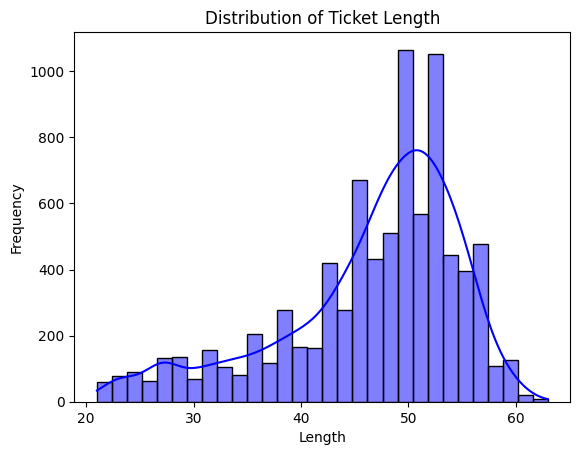

In [6]:
data_df['text_length'] = data_df['Ticket Description'].apply(lambda x: len(str(x).split()))

sns.histplot(data_df['text_length'], bins=30, kde=True, color='blue')
plt.title("Distribution of Ticket Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

The Ticket length distribution is a left skewed data set

In [7]:
print(data_df['text_length'].describe())

count    8469.000000
mean       46.467352
std         8.461730
min        21.000000
25%        43.000000
50%        49.000000
75%        52.000000
max        63.000000
Name: text_length, dtype: float64


The mean text length is 46 which is good enough to form clusters

In [8]:
columns = data_df.columns
for column in columns:
    duplicate_count = data_df[str(column)].duplicated().sum()
    print(f"Duplicate rows in {column}: {duplicate_count}")


Duplicate rows in Ticket ID: 0
Duplicate rows in Customer Name: 441
Duplicate rows in Customer Email: 149
Duplicate rows in Customer Age: 8416
Duplicate rows in Customer Gender: 8466
Duplicate rows in Product Purchased: 8427
Duplicate rows in Date of Purchase: 7739
Duplicate rows in Ticket Type: 8464
Duplicate rows in Ticket Subject: 8453
Duplicate rows in Ticket Description: 392
Duplicate rows in Ticket Status: 8466
Duplicate rows in Resolution: 5699
Duplicate rows in Ticket Priority: 8465
Duplicate rows in Ticket Channel: 8465
Duplicate rows in First Response Time: 2998
Duplicate rows in Time to Resolution: 5740
Duplicate rows in Customer Satisfaction Rating: 8463
Duplicate rows in text_length: 8426


There are a lot of duplicate values present. This make sense for the columns which are repetitive such as ticket status, ticket subject, ticket type which are categorized into groups our main focous is on the Ticket Description which we will be feeding into the model. This has around 392 duplicates which needs to be cleaned up before processing it or giving it to the model

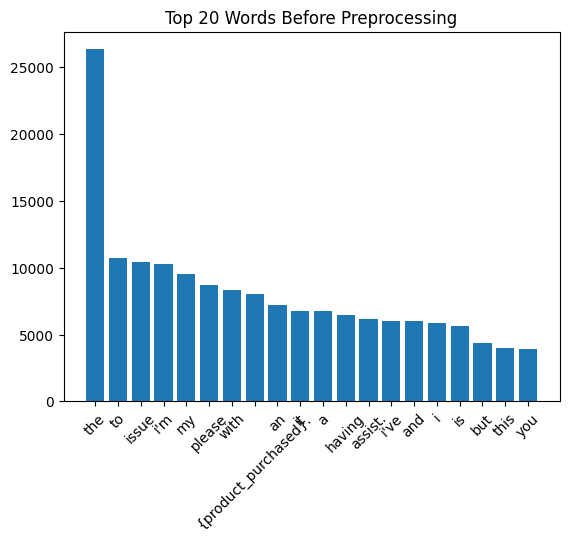

In [9]:
text_data = data_df['Ticket Description'].astype(str)

all_words = " ".join(text_data).lower().split()
common_words = Counter(all_words).most_common(20)

words, counts = zip(*common_words)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words Before Preprocessing")
plt.show()

The Above image show the top 20 word counts before preprocessing. As seen above there are lot of stop words and unnecessary ones which needs to be cleaned up before providing the data for vectorization and modeling.

In [10]:
unique_words = set(all_words)
print("Vocabulary size:", len(unique_words))

Vocabulary size: 13826


We have 13826 unique words present which includes both neceesary words and unnecssary words

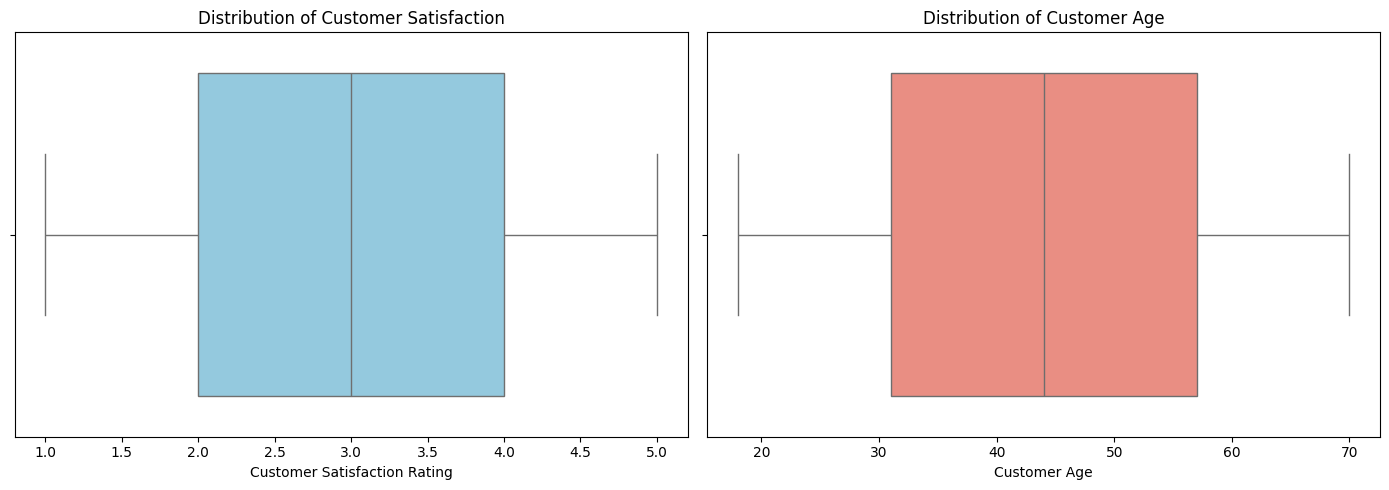

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=data_df['Customer Satisfaction Rating'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Customer Satisfaction')
sns.boxplot(x=data_df['Customer Age'], ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Customer Age')
plt.tight_layout()
plt.show()

There is high equality in terms of customer demography and satisfaction levels among the customers. The average age of the customer is around 45 years, with an average satisfaction level of 3/5. There are no outliers in this particular case; therefore, there are no edge cases affecting the data distribution.

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


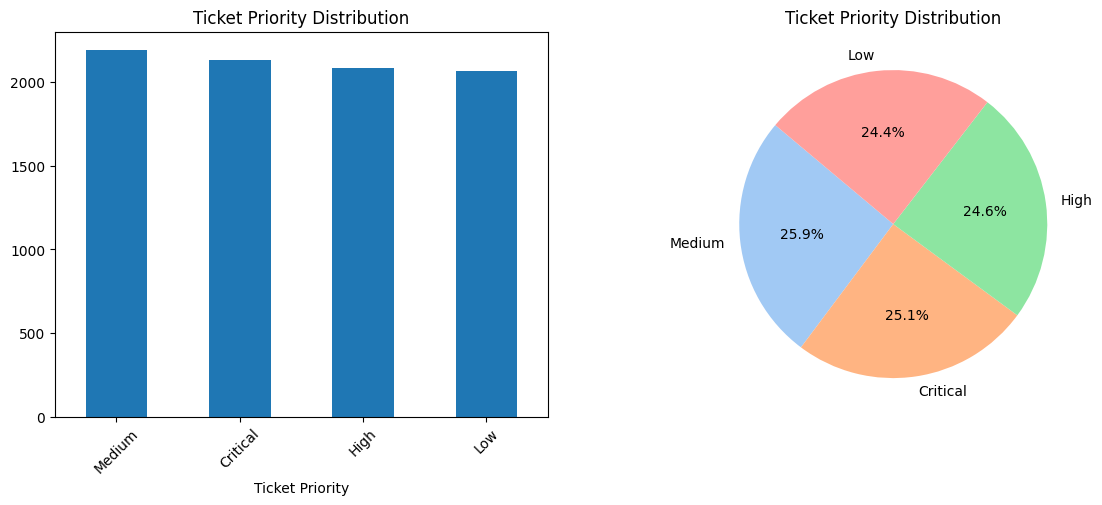

In [12]:
print(data_df['Ticket Priority'].value_counts())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data_df['Ticket Priority'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title("Ticket Priority Distribution")
axes[0].tick_params(axis='x', rotation=45)
data_df['Ticket Priority'].value_counts().plot(kind='pie', ax=axes[1],autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1].set_title("Ticket Priority Distribution")
plt.show()

The good thing about this is the distribution of the ticket priority is evenly distributed. Where Medium ticket marks the highest with a percentage of 25.9% and total of 2192 tickets and then next is the Critical ticket with a total of 2129 and contributing 25.1% percent from the total

Customer Satisfaction Rating
3.0    580
1.0    553
2.0    549
5.0    544
4.0    543
Name: count, dtype: int64


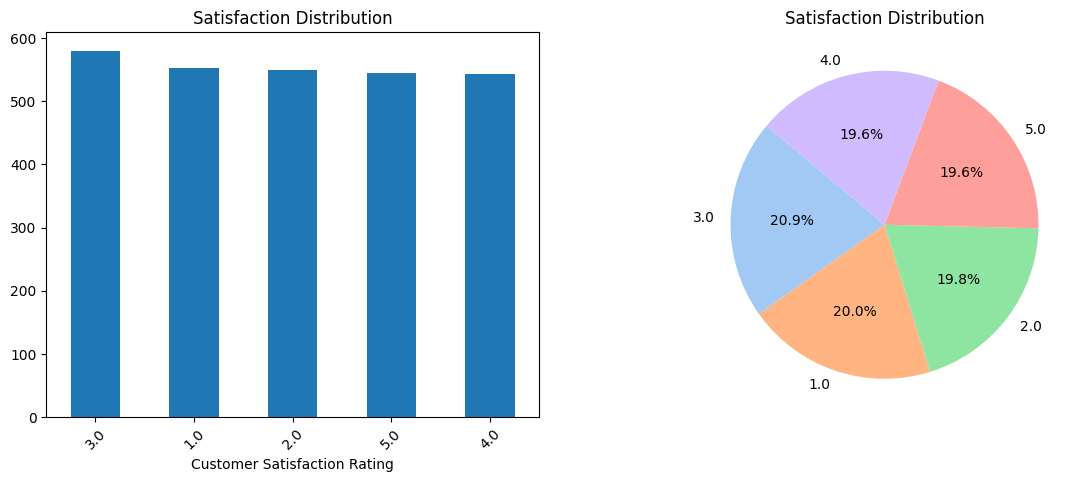

In [13]:
print(data_df['Customer Satisfaction Rating'].value_counts())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data_df['Customer Satisfaction Rating'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title("Satisfaction Distribution")
axes[0].tick_params(axis='x', rotation=45)
data_df['Customer Satisfaction Rating'].value_counts().plot(kind='pie', ax=axes[1],autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1].set_title("Satisfaction Distribution")      
plt.show()

The Satisfaction distribution is even but if we see there are 1.0 rating and 3.0 rating more compared to the rest.

Product Purchased
Sony Xperia                24
Canon EOS                  23
Amazon Kindle              19
Fitbit Versa Smartwatch    18
Microsoft Office           17
Bose QuietComfort          17
LG OLED                    17
Philips Hue Lights         17
Nintendo Switch            16
Sony 4K HDR TV             16
Name: count, dtype: int64


Text(0.5, 1.0, 'Top 20 Products in Least Satisfied Tickets')

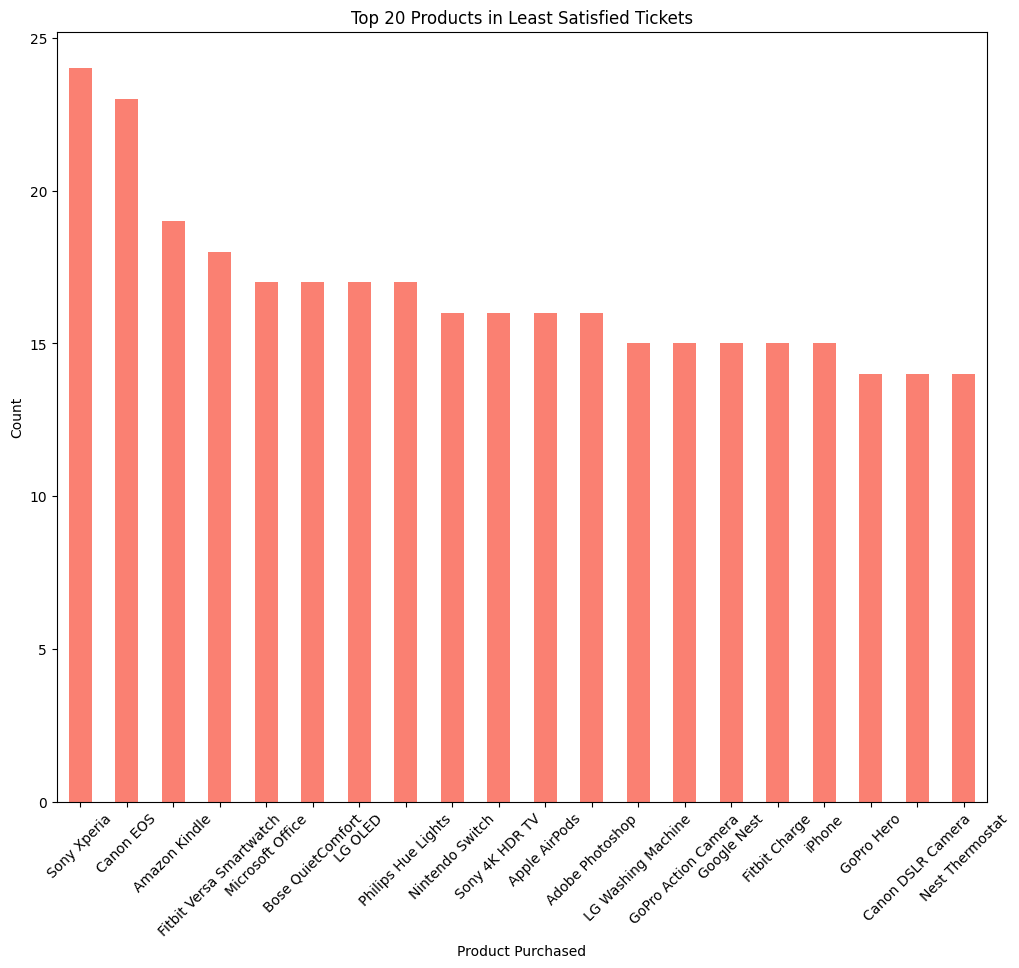

In [40]:
least_satisfied_products = data_df[data_df['Customer Satisfaction Rating'] == 1]
print(least_satisfied_products['Product Purchased'].value_counts().nlargest(10))
least_satisfied_products['Product Purchased'].value_counts().nlargest(20).plot(kind='bar', figsize=(12, 10), color='salmon')
plt.xlabel("Product Purchased")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.title("Top 20 Products in Least Satisfied Tickets")




Sony Xperia and Canon EOS marks the highest number of unsatisfied customer tickets which accounts to 24 and 23

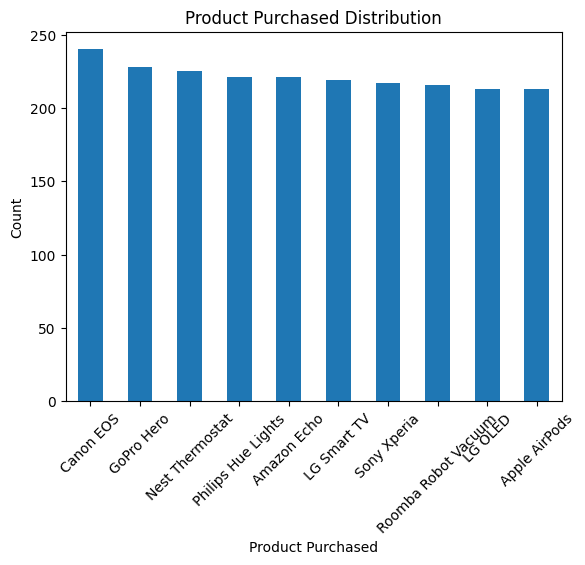

In [14]:
data_df['Product Purchased'].value_counts().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Product Purchased Distribution")
plt.xlabel("Product Purchased")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

Canon EOS is the highest purchased product

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


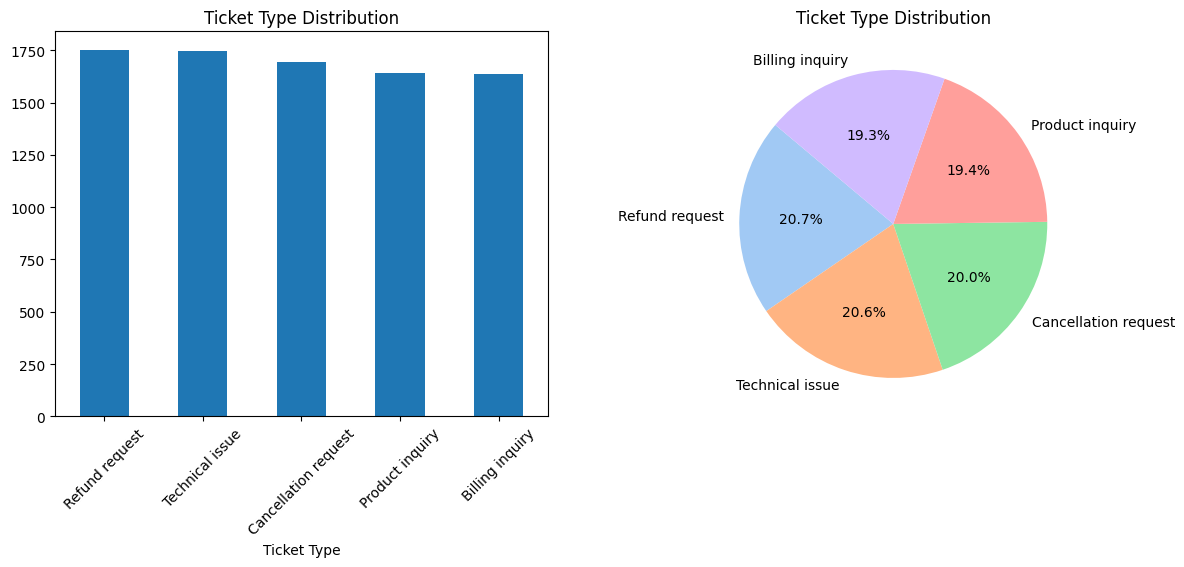

In [15]:
print(data_df['Ticket Type'].value_counts())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data_df['Ticket Type'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title("Ticket Type Distribution")
axes[0].tick_params(axis='x', rotation=45)
data_df['Ticket Type'].value_counts().plot(kind='pie', ax=axes[1],autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1].set_title("Ticket Type Distribution")      
plt.show()

These are like the ground truth values. Meaning we can use these ticket type to evalute the clusters

Product Purchased
Sony Xperia            52
Sony PlayStation       52
Nikon D                51
Amazon Echo            51
Canon EOS              50
Canon DSLR Camera      50
GoPro Hero             50
Nest Thermostat        49
Dell XPS               49
Roomba Robot Vacuum    48
Name: count, dtype: int64


Text(0.5, 1.0, 'Top 20 Products in Refund Tickets')

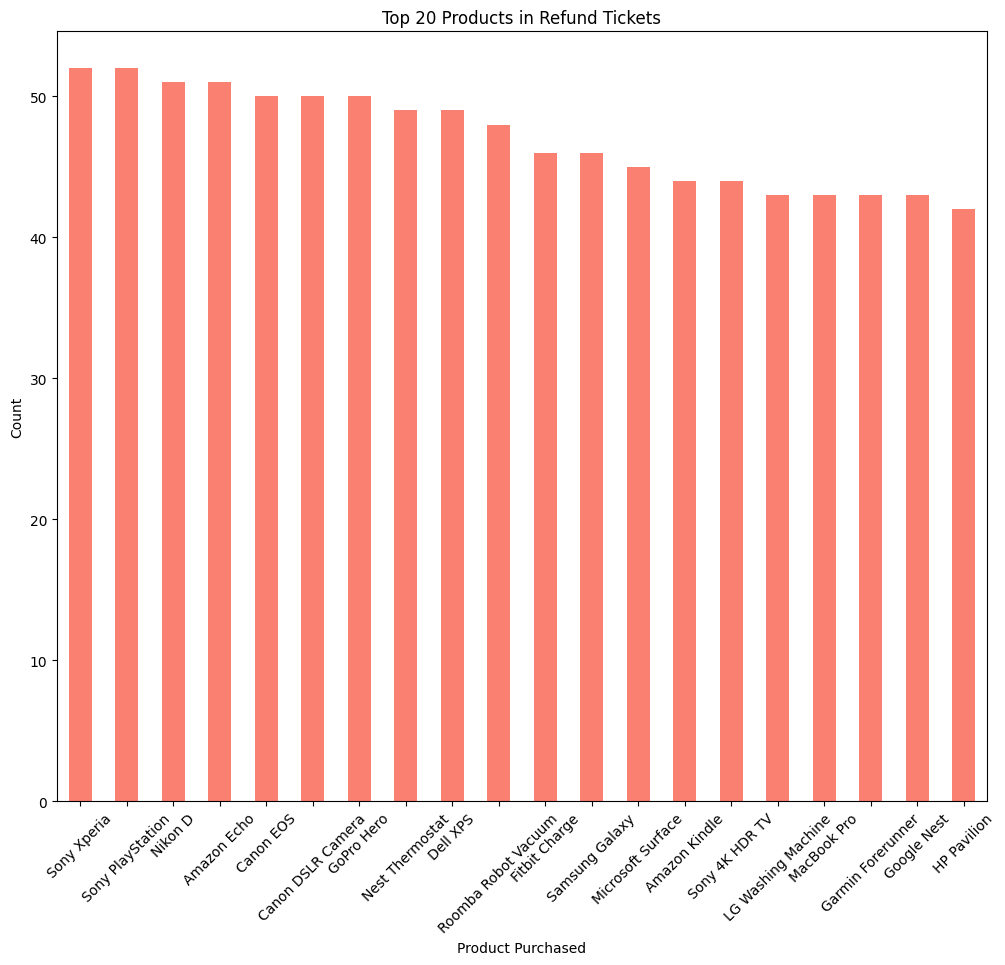

In [39]:
refund_products = data_df[data_df['Ticket Type'] == 'Refund request']
print(refund_products['Product Purchased'].value_counts().nlargest(10))
refund_products['Product Purchased'].value_counts().nlargest(20).plot(kind='bar', figsize=(12, 10), color='salmon')
plt.xlabel("Product Purchased")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.title("Top 20 Products in Refund Tickets")

Sony Xperia and Sony playstation is the highest product with the tickets which require a refund and has a count of 52

Product Purchased
GoPro Hero              57
Amazon Echo             48
Garmin Forerunner       48
Canon EOS               48
Apple AirPods           46
LG Washing Machine      46
Amazon Kindle           46
Nest Thermostat         45
Philips Hue Lights      45
Dyson Vacuum Cleaner    44
Name: count, dtype: int64


Text(0.5, 1.0, 'Top 20 Products in Technical Issues Tickets')

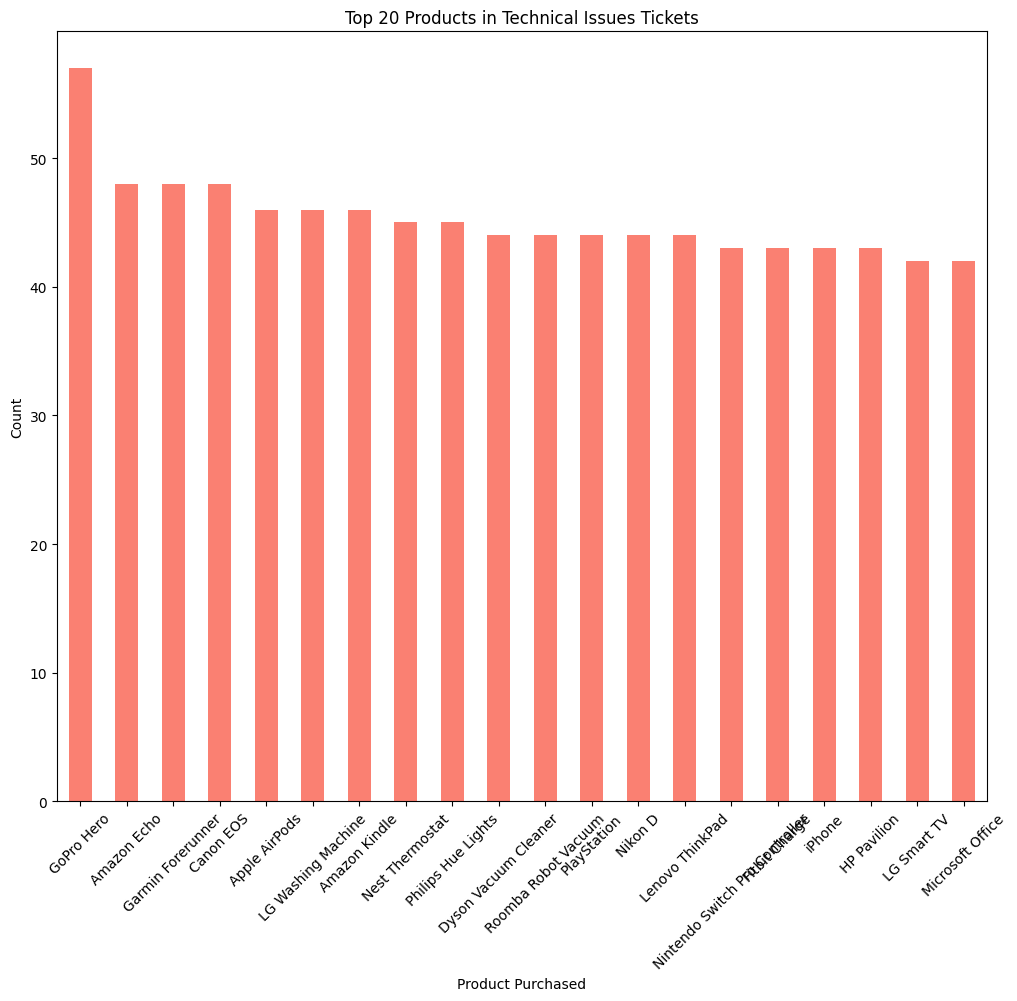

In [44]:
techissue_products = data_df[data_df['Ticket Type'] == 'Technical issue']
print(techissue_products['Product Purchased'].value_counts().nlargest(10))
techissue_products['Product Purchased'].value_counts().nlargest(20).plot(kind='bar', figsize=(12, 10), color='salmon')
plt.xlabel("Product Purchased")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.title("Top 20 Products in Technical Issues Tickets")

GoPro Hero              57  
Amazon Echo             48  
Garmin Forerunner       48  
Canon EOS               48  
Are the highest number of product which have had technical issues

Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64


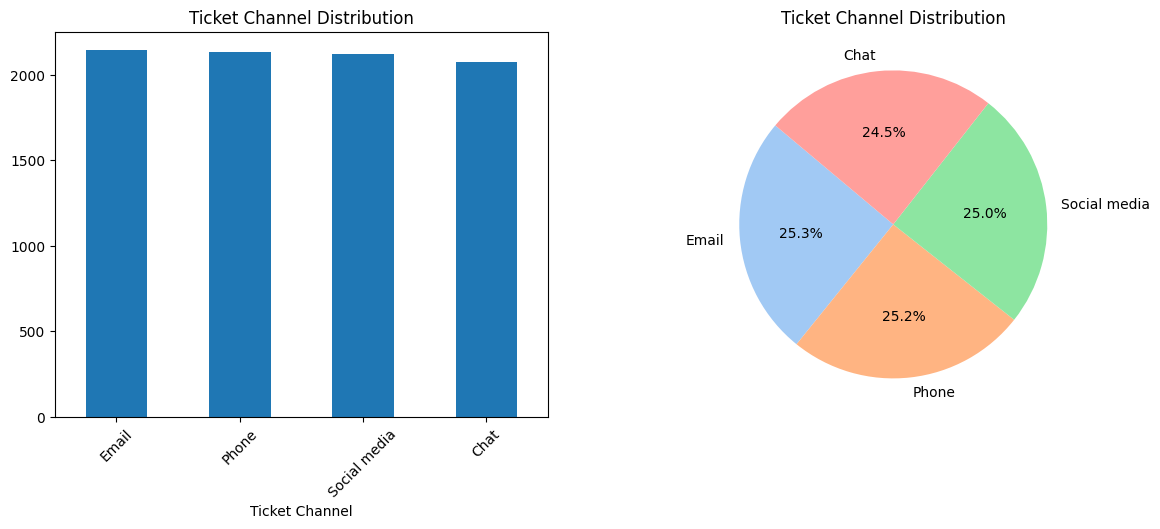

In [16]:
print(data_df['Ticket Channel'].value_counts())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data_df['Ticket Channel'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title("Ticket Channel Distribution")
axes[0].tick_params(axis='x', rotation=45)
data_df['Ticket Channel'].value_counts().plot(kind='pie', ax=axes[1],autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1].set_title("Ticket Channel Distribution")      
plt.show()

There is no dominant communication channel in the dataset and the negligible variance between the most used, Email at 25.3% and least used, Chat at 24.5% suggests a highly balanced multi channel ticket communication.

In [17]:
data_df['Ticket Subject'].value_counts()

Ticket Subject
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478
Name: count, dtype: int64

Although the predefined ticket subject labels provide useful categorisation, they are predefined and overlapping. Therefore, we cannot use them ground truth, as the objective of this study is to identify higher level themes that provide more actionable insights.

In [18]:
data_df['Customer Age'].agg(['mean', 'max', 'min'])

mean    44.026804
max     70.000000
min     18.000000
Name: Customer Age, dtype: float64

The customer age description is as mentioned above with the mean age of the customer being 44 years

In [19]:
data_df['Date of Purchase'].agg(['max', 'min'])

max    2021-12-30
min    2020-01-01
Name: Date of Purchase, dtype: str

We have the range of date from which the products are purchased. The first sale being made on 1st Jan 2020 and the last sale being made on 30th Dec of 2021

Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64


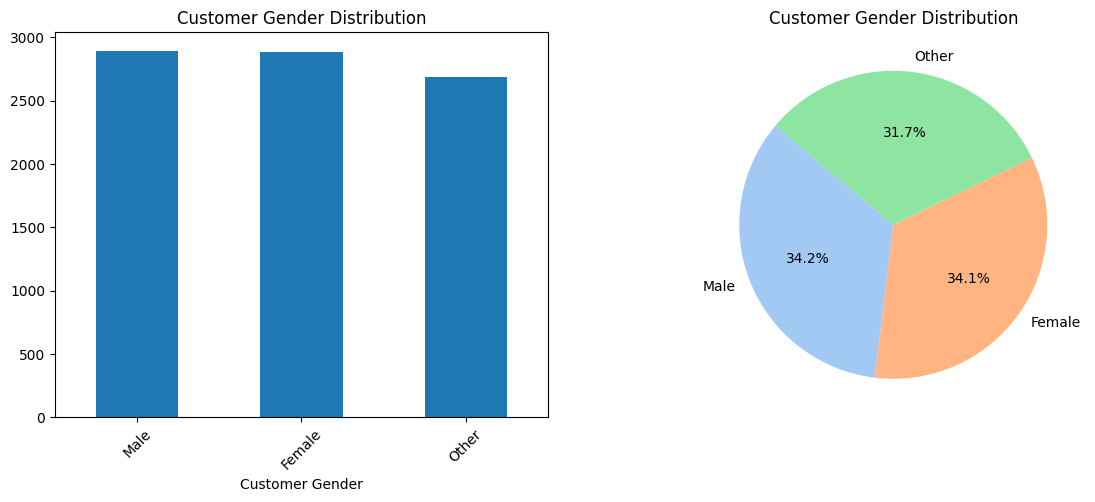

In [20]:
print(data_df['Customer Gender'].value_counts())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data_df['Customer Gender'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title("Customer Gender Distribution")
axes[0].tick_params(axis='x', rotation=45)
data_df['Customer Gender'].value_counts().plot(kind='pie', ax=axes[1],autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1].set_title("Customer Gender Distribution")      
plt.show()

From the customer age distribution we can see that the ratio of the genders are balanced with almost equal percentage of distribution between male, female and others

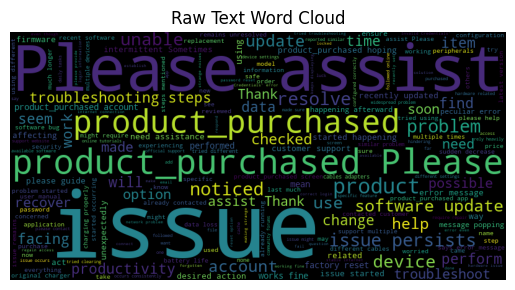

In [21]:
wordcloud = WordCloud(width=800, height=400).generate(" ".join(text_data))

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Raw Text Word Cloud")
plt.show()

The word cloud presents the most used words in the ticket description. As we can see from that Please assist, Product_purchased have appeared multiple number of times and needs to be cleaned to form good clusters

In [22]:
results_list = []
count = 0

for i in range(len(data_df['Ticket Description'])):
    text = data_df['Ticket Description'][i]
    matches = re.findall(r'\{.*?\}', text)
    if matches:
        results_list.append(f"Found patterns in ticket {i}: {matches}")
        count += 1
print(f"Total tickets with patterns: {count}")
for line in results_list[:10]:
    print(line)


Total tickets with patterns: 8469
Found patterns in ticket 0: ['{product_purchased}']
Found patterns in ticket 1: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 2: ['{product_purchased}', '{product_purchased}', '{product_purchased}']
Found patterns in ticket 3: ['{product_purchased}']
Found patterns in ticket 4: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 5: ['{product_purchased}', '{product_purchased}', "{product_purch I've checked for any available software updates for my {product_purchased}"]
Found patterns in ticket 6: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 7: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 8: ['{product_purchased}', '{product_purchased}', '{product_purchased}']
Found patterns in ticket 9: ['{product_purchased}']


We will have to remove these text messages so that the clusters can come out good. The model will detect there are the highest number of words and will get confused while clustering. These words are presnet in almost every line of the data set as seen with the count.

## Bivariate Analysis

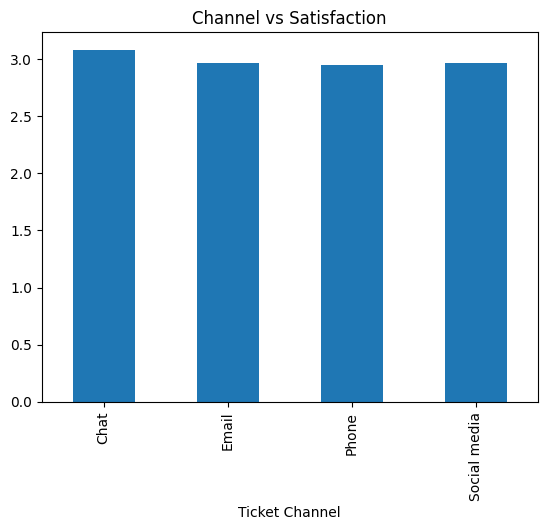

In [23]:
data_df.groupby('Ticket Channel')['Customer Satisfaction Rating'].mean().plot(kind='bar')
plt.title("Channel vs Satisfaction")
plt.show()

The Average customer satisfaction rating is almost the same across all the channel. That is 3.0 so we dont have an issue with respect to media in which the tickets are collected.

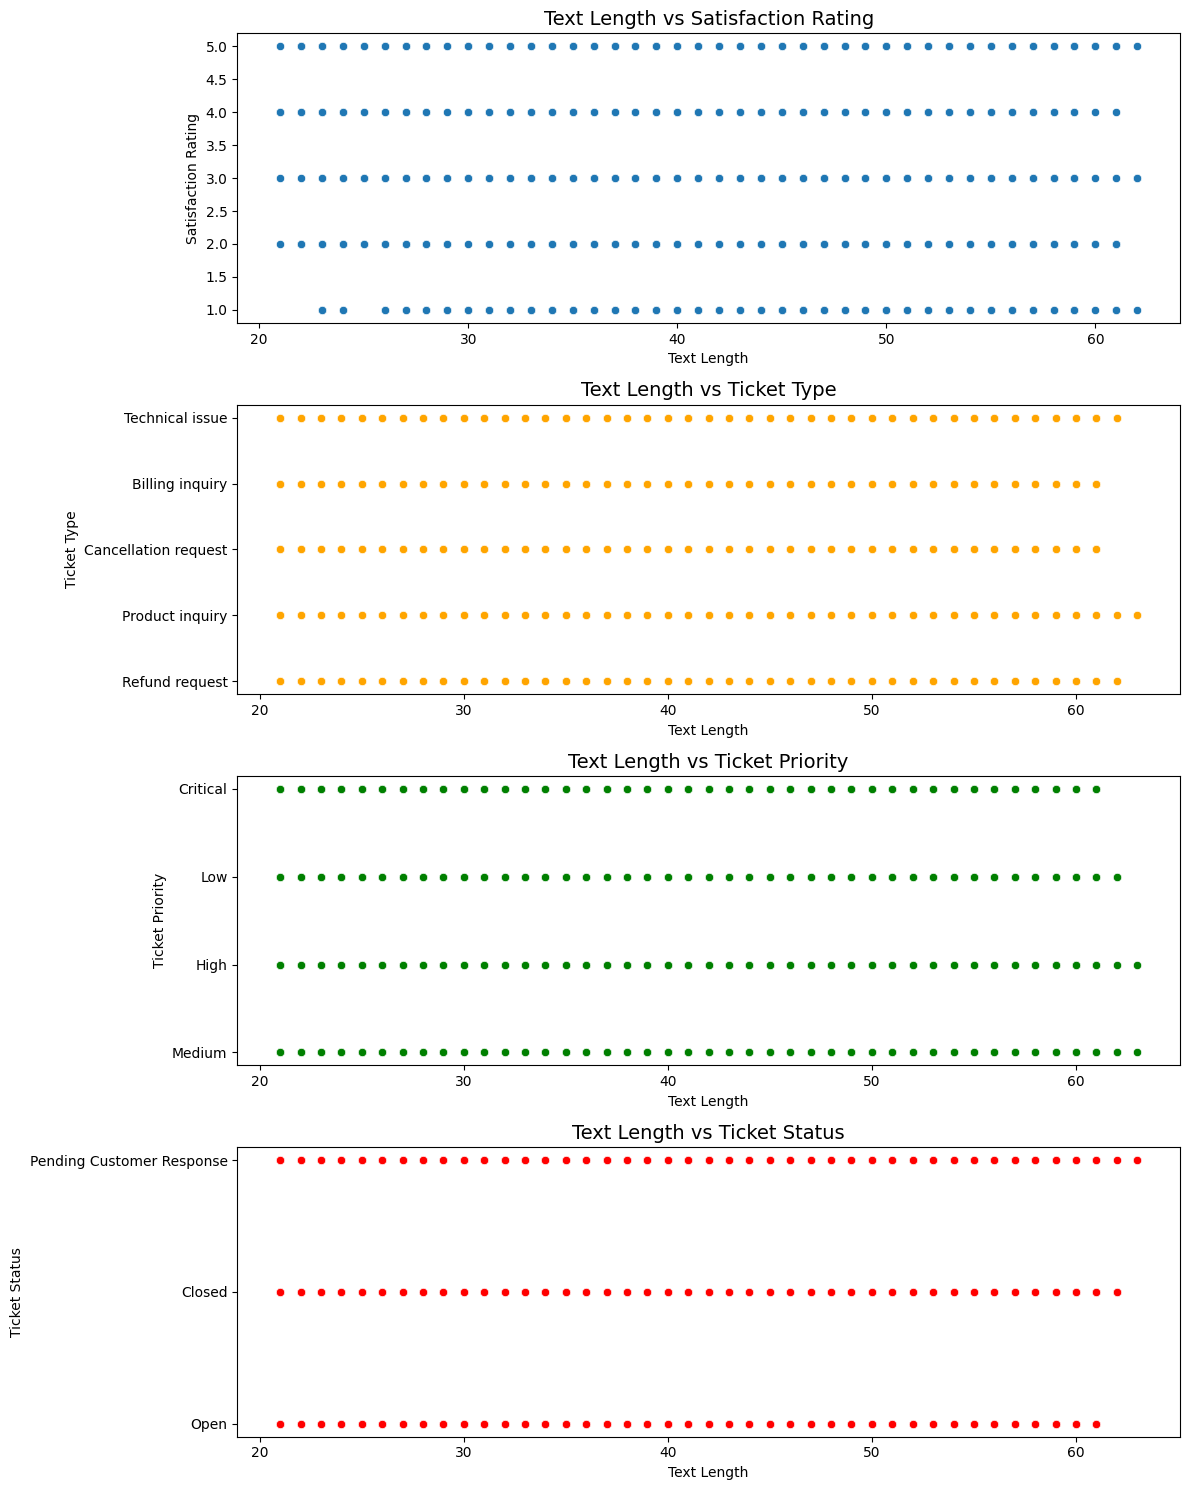

In [24]:
fig, axes = plt.subplots(4, 1, figsize=(12, 15))
sns.scatterplot(data=data_df, x='text_length', y='Customer Satisfaction Rating', ax=axes[0])
axes[0].set_title("Text Length vs Satisfaction Rating", fontsize=14)
axes[0].set_xlabel("Text Length")
axes[0].set_ylabel("Satisfaction Rating")
sns.scatterplot(data=data_df, x='text_length', y='Ticket Type', ax=axes[1], color='orange')
axes[1].set_title("Text Length vs Ticket Type", fontsize=14)
axes[1].set_xlabel("Text Length")
axes[1].set_ylabel("Ticket Type")
sns.scatterplot(data=data_df, x='text_length', y='Ticket Priority', ax=axes[2], color='green')
axes[2].set_title("Text Length vs Ticket Priority", fontsize=14)
axes[2].set_xlabel("Text Length")
axes[2].set_ylabel("Ticket Priority")
sns.scatterplot(data=data_df, x='text_length', y='Ticket Status', ax=axes[3], color='red')
axes[3].set_title("Text Length vs Ticket Status", fontsize=14)
axes[3].set_xlabel("Text Length")
axes[3].set_ylabel("Ticket Status")
plt.tight_layout()
plt.show()

Since the Scatter plot is linear this goes to say that there is no correlation between the ticket description with that of Satisfaction rating, Ticket Type, Ticket Priority and Ticket Status.

Ticket Priority       Critical  High  Low  Medium
Ticket Type                                      
Billing inquiry            420   382  398     434
Cancellation request       423   398  414     460
Product inquiry            403   399  398     441
Refund request             444   448  440     420
Technical issue            439   458  413     437


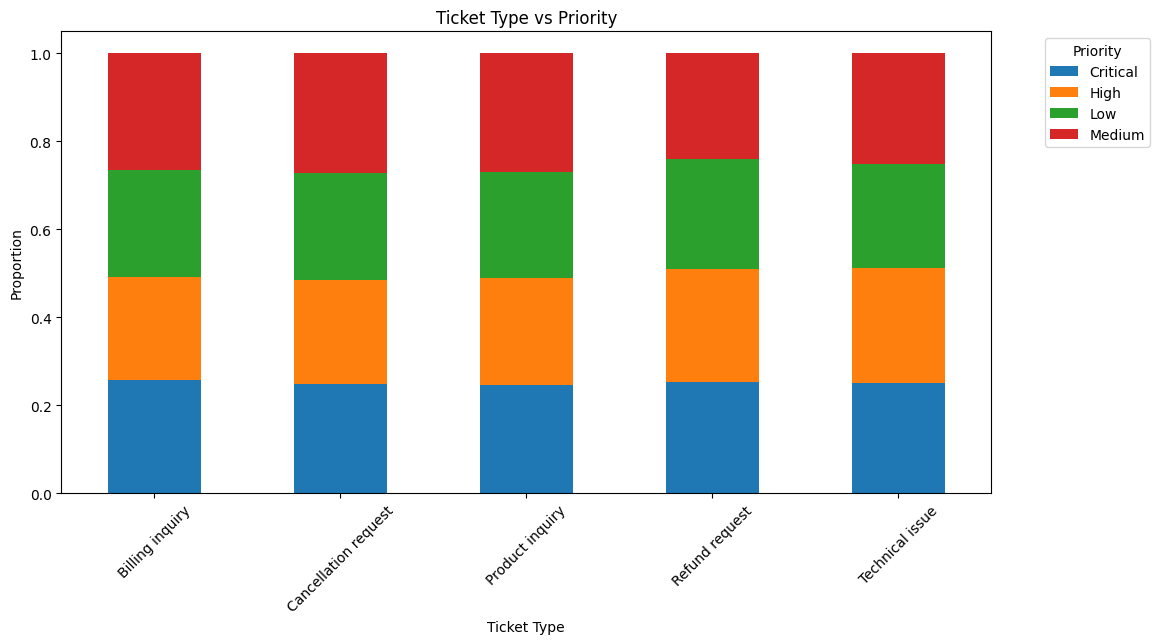

In [25]:
print(pd.crosstab(data_df['Ticket Type'], data_df['Ticket Priority']))
plt.figure(figsize=(12, 6)) 
data_df_ct = pd.crosstab(data_df['Ticket Type'], data_df['Ticket Priority'], normalize='index')
data_df_ct.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Ticket Type vs Priority")
plt.xlabel("Ticket Type")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title='Priority', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The composition of ticket priorities is virtually identical across all ticket types which confirms that the urgency of a request is independent of its category

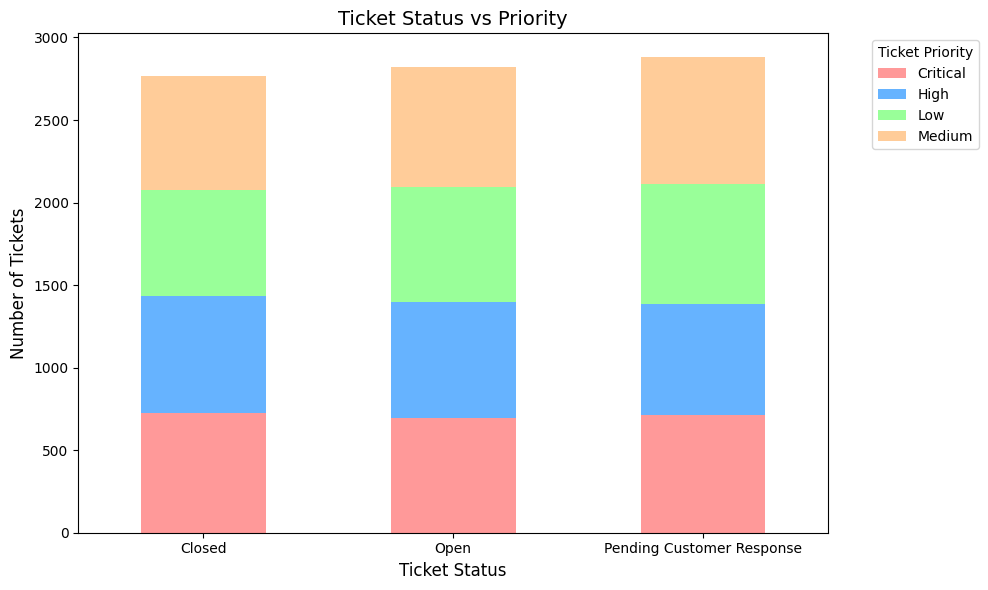

In [26]:
status_priority_map = pd.crosstab(data_df['Ticket Status'], data_df['Ticket Priority'])
status_priority_map.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#ff9999','#66b3ff','#99ff99','#ffcc99'])

plt.title("Ticket Status vs Priority", fontsize=14)
plt.xlabel("Ticket Status", fontsize=12)
plt.ylabel("Number of Tickets", fontsize=12)
plt.legend(title="Ticket Priority", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Ticket Priority     Critical  High  Low  Medium
Product Purchased                              
Canon EOS                 67    70   48      55
GoPro Hero                64    50   61      53
Nest Thermostat           62    44   53      66
Amazon Echo               54    55   57      55
Philips Hue Lights        53    59   49      60


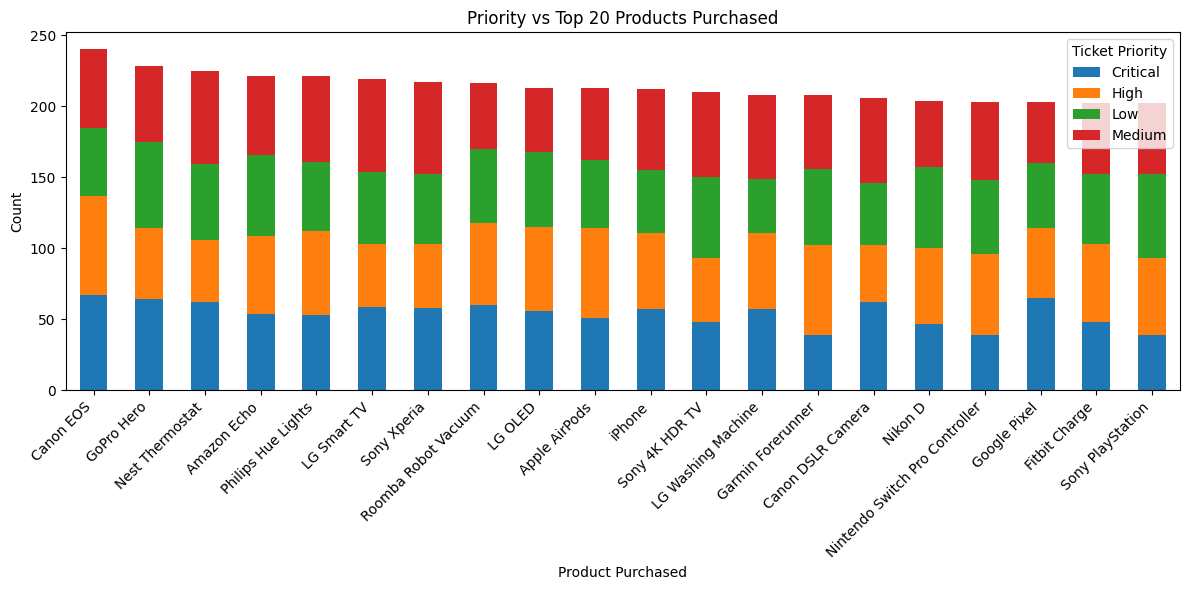

In [27]:
top_20_products = data_df['Product Purchased'].value_counts().nlargest(20).index
filtered_df = data_df[data_df['Product Purchased'].isin(top_20_products)]
plot_data = filtered_df.groupby(['Product Purchased', 'Ticket Priority']).size().unstack()
plot_data['Total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values('Total', ascending=False).drop(columns='Total')
print(plot_data.head())
plot_data.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Priority vs Top 20 Products Purchased")
plt.xlabel("Product Purchased")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Ticket Priority')
plt.tight_layout()
plt.show()

## Multivariant Analysis

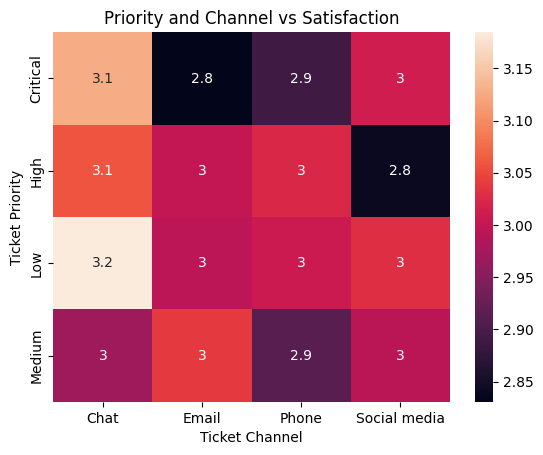

In [29]:
pivot = data_df.pivot_table(values='Customer Satisfaction Rating',index='Ticket Priority',columns='Ticket Channel',aggfunc='mean')
sns.heatmap(pivot, annot=True)
plt.title("Priority and Channel vs Satisfaction")
plt.show()

The dataset exhibits a high degree of categorical symmetry and statistical independence, indicating that ticket attributes such as ticket channel, ticket priority, and ticket description length have no measurable impact on customer satisfaction or resolution status

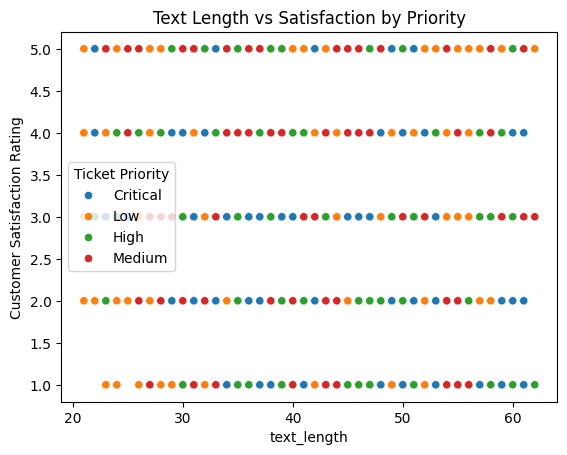

In [30]:
sns.scatterplot(data=data_df,x='text_length',y='Customer Satisfaction Rating',hue='Ticket Priority')
plt.title("Text Length vs Satisfaction by Priority")
plt.show()

The Above scatter plot shows that there is no relation between the ticket length, Customer satisfaction and ticket priority. The dataset is uniformly distributed

## Insights and Conclusion

### Insights

### Main Insights required for the NLP Pipeline

The dataset consists of 8469 entries across 17 distinct columns  
The Main column required for the NLP pipeline building is the Ticket Description  
The Length of the Ticket Description Column follows a left skewed pattern  
There are Null Values present in columns and these do not affect the NLP Pipeline
The Null Values and the respective columns are as mentioned below 
 1. Resolution: 5700 null values  
 2. First Response Time: 2819 null values  
 3. Time to Resolution: 5700 null values  
 4. Customer Satisfaction Rating: 5700 null values  
 
The Mean text length in the ticket discription column is 46 which is good enough to form clusters 
There are lot of duplicates present in the data but for categorical columns which has groups it is fine but we are focused on ticket description and it has around 392 duplicate rows present in it which needs to be cleaned up 
The columns such as Ticket type distribution, Customer Satisfaction rating are evenly distributed  
The Data set is a balanced data set when it comes to the evenly distributed columns  
Ticket Description has no correlation with any of the ticket status, Ticket Channel, Customer Satisfaction columns and is completely independent
The Ticket description has a lot of noise in it such as product_purchased etc which needs to be cleaned up  
The word cloud consists of lot of stop words which needs to be filtered out before given to the model  
The Ticket subject which has around 16 sub categories are not human written but is system generated. Good thing about these are they are evenly distributed in the data set These are mentioned below  
 1. Refund request  
 2. Software bug  
 3. Product compatibility  
 4. Delivery problem  
 5. Hardware issue  
 6. Battery life  
 7. Network problem  
 8. Installation support  
 9. Product setup  
 10. Payment issue  
 11. Product recommendation  
 12. Account access  
 13. Peripheral compatibility  
 14. Data loss  
 15. Cancellation request  
 16. Display issue  

We have around 5 categories of ticket or ticket types as mentioned below  
Ticket Type  
 1. Refund request  
 2. Technical issue  
 3. Cancellation request  
 4. Product inquiry  
 5. Billing inquiry  



### Other Observations

The given dataset is a balanced data set between most of the features  
The ticket distribution is even which is approximately 20-25% from each category but Medium ticket marks the highest with a percentage of 25.9% and total of 2192 tickets and then next is the Critical ticket with a total of 2129 and contributing 25.1% percent from the total.  
Ticket Channel distribution is also even. Which means to say that people are using all the channels to raise tickets and also talk about the issue. In the equally distributed channel Email seems to be most prominent media which is used which is 25.3%.  
Canon EOS is the highest number of purchased product.  
Customers seems to be more anxious on the refund request as there are lot of tickets in that category as there around 444 critical tickets and 448 high priority tickets.  
Sony Xperia and Sony Playstation are the one which the highest number of tickets with Refund request  
Sony Xperia and Canon have the highest no of ticket which have least satisfaction rates from the customer end  
The data set contains records starting from 2020-01-01 to 2021-12-30   
There are lot of products which technical issues that is GoPro Hero, Amazon Echo, Garmin Forerunner and Canon EOS


### Recommendations

Goal of the company must be to reduce the total number of tickets  
There are lot of tickets with critical and medium priority which needs to be address as to why  
Medium Priority tickets are the most common at 25.9%
Most of the critical tickets are for the products with refund request and needs to be tackled  
Canon EOS is the highest purchased product but it also has high number of least satisfaction rate.
The product select based on the rate comprise of 10% of the total as there are about 552 least satisfied ticket and approx 50 is for canon  
There are lot of tickets on refunds and customers seems to be very anxious on it. The company has to reduce these number of tickets
Most of the refund request tickets are for the Sony Xperia and Sony Playstation. Company has to check as to why
The Second Highest issues is the Technical Issues and the products that are experiencing these are GoPro Hero, Amazon Echo, Garmin Forerunner and Canon EOS and company has to work on seeing as to why  
Also there are lot of missing values pertaining to the resolutions of the ticket. Operation team has to figure out why and populate these data

## Next Steps

### Building NLP Pipeline

This Data set can be used to build the NLP pipeline and we will proceed further with Topic Modelling  
There are around 16 different ticket subject but we will not take this as the ground truth but will consider the ticket type of 5 columsn to be the ground truth while comparing due to this we will max form clusters in the range of 2-10 while using Kmeans and HAC for topic modelling. This way the clusters will be more interpretable and easier to classify.
The mean of ticket lenght is good enough to use it for clustering.  
We will not be merging any of the ticket subject or ticket type with the descriptiong to form clusters as this will cause more noise and hinder from forming clusters.  
We will have to put in so many custom words apart from the stop words while filtering for TFIDF  
We will have to remove the words in the {}, the links which are present and some conjoint words.  
We will have to do lemmetization for TFIDF  
We will have to bring all the words into lowercases  
These are the estimated steps which will be done before modelling.  
For modelling we will be using  
TFIDF + Kmeans  
TFIDF + HAC  
Vectorization + LDA  
Embeddings + Kmeans  
Embeddings + HAC  
Embeddings + Bert

Post modelling
we will draw the conclusiong from the custers formed by it and provide deeper insights of the issues
